<div align="center">

# 📊 **ĐỒ ÁN NHÓM MÔN DS108**

---

## 👥 Thành viên thực hiện

| Họ và tên             |     MSSV     |
| :-------------------- | :----------: |
| **Võ Thụy Sao Mai**   | **24521038** |
| **Nguyễn Quang Minh** | **24521075** |

---

📅 Năm học 2025–2026
🏫 Trường Đại học Công nghệ Thông tin (UIT) – ĐHQG TP.HCM

</div>


## Instruction List
### Dự án gồm 3 phần chính:
* Phần I: Thu thập dữ liệu (n1_data_collection)
* Phần II: Tiền xử lý dữ liệu (n2_data_cleaning_and_imputation)
* Phần III: Phân tích khám phá dữ liệu (n3_exploratory_data_analysis)

In [1]:
import numpy as np
import pandas as pd
from pyampute.exploration.mcar_statistical_tests import MCARTest
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from n2_data_cleaning_and_imputation.imputation import *
from n2_data_cleaning_and_imputation.utils import *
from n2_data_cleaning_and_imputation.cleaning import *
from n2_data_cleaning_and_imputation.feature_engineering import *
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# **Phần I: Thu thập dữ liệu (n1_data_collection)**
_ Người dùng vui lòng sử dụng các công cụ thu thập nằm trong thư mục **n1_data_collection**. Bao gồm mã nguồn cào thông tin từ 2 trang web ShopeeFood và Foody có tên lần lượt là **crawl_from_shopee.ipynb** và **crawl_from_shopee.ipynb**. Hướng dẫn sử dụng đã có trong từng file

# **Phần II: Tiền xử lý dữ liệu (n2_data_cleaning_and_imputation)**

# I. Phân tích bình luận để gán nhãn

* Gộp dữ liệu từ shopee và foody(nếu được tăng cường) của từng số hiệu file thuộc 6 tỉnh (đồng thời phân tích bình luận)

In [ ]:
sp_path_D = Path(r"../data/data_raw/shopee_csv/D") # Đường dẫn đến thư mục chứa file shopee
fd_path_D = Path(r"../data/data_raw/foody_csv/D") # Đường dẫn đến thư mục chứa file foody
sp_ids = [int(file.stem[1:]) for file in sp_path_D.iterdir() if file.is_file() and file.stem[1:].isdigit()] # Tất cả số hiệu file shopee
fd_ids = [int(file.stem[1:]) for file in fd_path_D.iterdir() if file.is_file() and file.stem[1:].isdigit()] # Tất cả số hiệu file foody
entire_ids = list(set(sp_ids) | set(fd_ids))

# Kết hợp file shopee và foody tương ứng (nếu được tăng cường)
for id in entire_ids[entire_ids.index(1000):entire_ids.index(1000)+1]: # Có thể đổi số hiệu file trong phần .index(), demo ở file 13
    sp_file = Path(f"../data/data_raw/shopee_csv/D/D{id}.csv")
    fd_file = Path(f"../data/data_raw/foody_csv/D/D{id}.csv")
    sp_id = fd_id = None # Khởi tạo số hiệu file
    if sp_file.is_file():
        sp_id = id
    if fd_file.is_file():
        fd_id = id
    # Hàm gộp dữ liệu shopee và foody, đồng thời tính điểm foody nếu có
    sp_fd = combine_shopee_foody(sp_id, fd_id)
    if sp_fd is not None:
        sp_fd.to_csv(f"../data/data_raw/sp_fd_csv/D{id}.csv", index=False, encoding='utf-8-sig')

* Tổng hợp tất cả các file thành 1 dataframe

In [3]:
df_lst = []
sp_fd_path = Path(r"../data/data_raw/sp_fd_csv")
for file in sp_fd_path.iterdir():
    if file.is_file() == False: continue
    file = pd.read_csv(file)
    df_lst.append(file)
combined_df = pd.concat(df_lst, ignore_index=True)

* Chia Train-Test

In [4]:
train_df, test_df = train_test_split(combined_df, test_size=0.2, shuffle= True, random_state=42)

* Gán nhãn

In [5]:
annotator = LabelProcessor(label_annotating_func=label_annotating)
train_df = annotator.fit_transform(train_df)
test_df = annotator.transform(test_df)

# Tạo file .csv cho dữ liệu tổng hợp (raw_data) sau khi đã gán nhãn
train_df.to_csv(r"../data/data_raw/train/train_raw.csv", index=False, encoding='utf-8-sig')
test_df.to_csv(r"../data/data_raw/test/test_raw.csv", index=False, encoding='utf-8-sig')
print(f"Số dòng dữ liệu thô: {len(train_df)}")

Đã fit xong: q1=3.5000, q2=4.4000
Số dòng dữ liệu thô: 13140


# II. Thống kê sơ bộ

### Phần EDA chi tiết dữ liệu thô sau thu thập đã có trong file: **notebooks/n3_exploratory_data/EDA_raw.ipynb**. Kính mời độc giả đọc qua.

In [6]:
train_df = pd.read_csv(r"../data/data_raw/train/train_raw.csv")
test_df = pd.read_csv(r"../data/data_raw/test/test_raw.csv")

* Kích thước và kiểu dữ liệu từng cột

In [7]:
print("Số dòng train:", len(train_df), "| Số cột train:", train_df.shape[1])
print("Số dòng test:", len(test_df), "| Số cột test:", test_df.shape[1])
display(pd.DataFrame({'Kiểu dữ liệu': train_df.dtypes}))

# Chuẩn hóa định dạng cột categorical
train_df = normalize_categorical_columns(train_df, train_df.columns)
test_df = normalize_categorical_columns(test_df, test_df.columns)

Số dòng train: 13140 | Số cột train: 23
Số dòng test: 3286 | Số cột test: 23


,Kiểu dữ liệu
RestaurantID,int64
Restaurant Name,str
Latitude,float64
Longitude,float64
Address,str
Type,str
Cuisines,str
Monday,str
Tuesday,str
Wednesday,str


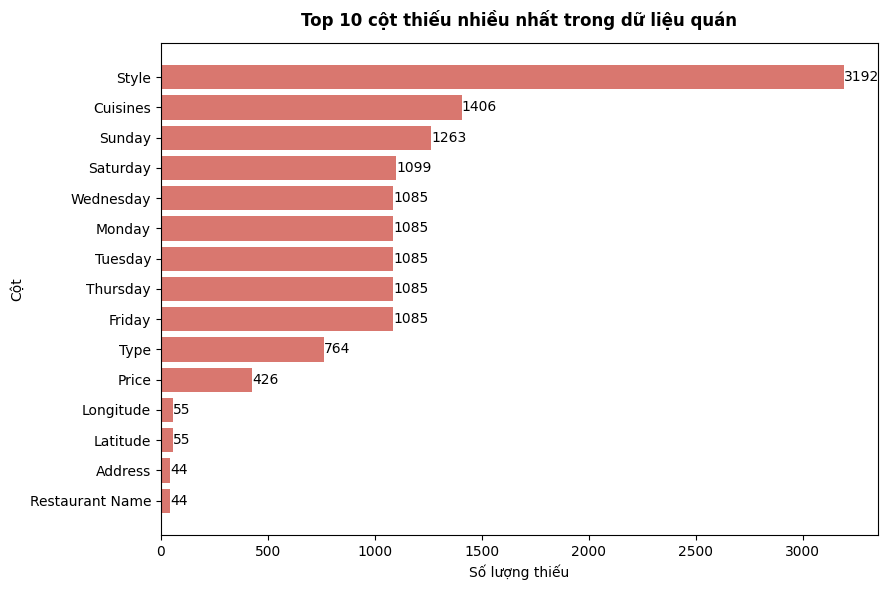

In [8]:
miss_train = pd.DataFrame({
    "Số lượng thiếu": combined_df.isna().sum(),
    "Tỉ lệ %": (combined_df.isna().sum()).round(1),
    "SL giá trị duy nhất": combined_df.nunique(dropna=True),
}).sort_values("Tỉ lệ %", ascending=False)

# Biểu đồ % thiếu theo cột (chỉ cột có thiếu)
m_train = miss_train[miss_train["Tỉ lệ %"] > 0].sort_values("Tỉ lệ %", ascending=True)
if len(m_train):
    plt.figure(figsize=(9, max(3, 0.4*len(m_train))))
    plt.barh(m_train.index, m_train["Tỉ lệ %"], color="#d9776f")
    plt.xlabel("Số lượng thiếu"); plt.title("Top 10 cột thiếu nhiều nhất trong dữ liệu quán", pad=12, fontweight="bold")
    plt.ylabel('Cột')
    for i, v in enumerate(m_train["Tỉ lệ %"]):
        plt.text(v+0.3, i, f"{v}", va="center")
    plt.tight_layout(); 
    plt.show()
else:
    print("Không có cột nào thiếu.")

* Tỉ lệ thiếu từng cột

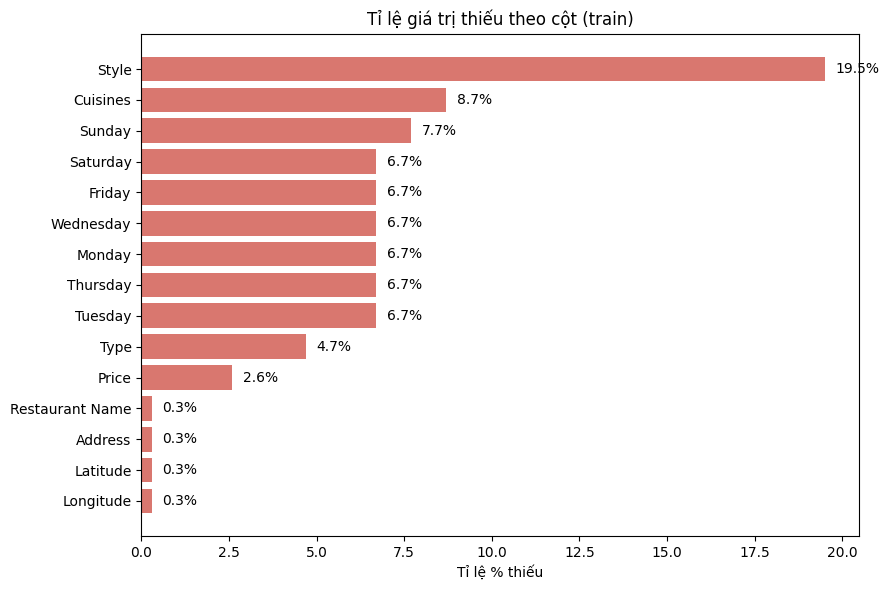

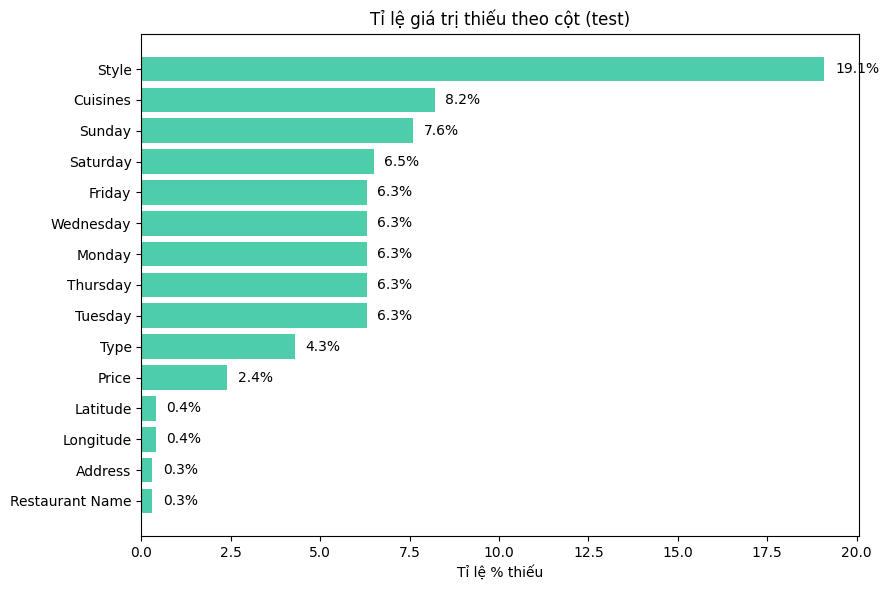

In [9]:
miss_train = pd.DataFrame({
    "Số lượng thiếu": train_df.isna().sum(),
    "Tỉ lệ %": (train_df.isna().mean()*100).round(1),
    "SL giá trị duy nhất": train_df.nunique(dropna=True),
}).sort_values("Tỉ lệ %", ascending=False)

miss_test = pd.DataFrame({
    "Số lượng thiếu": test_df.isna().sum(),
    "Tỉ lệ %": (test_df.isna().mean()*100).round(1),
    "SL giá trị duy nhất": test_df.nunique(dropna=True),
}).sort_values("Tỉ lệ %", ascending=False)

# Biểu đồ % thiếu theo cột (chỉ cột có thiếu)
m_train = miss_train[miss_train["Tỉ lệ %"] > 0].sort_values("Tỉ lệ %", ascending=True)
if len(m_train):
    plt.figure(figsize=(9, max(3, 0.4*len(m_train))))
    plt.barh(m_train.index, m_train["Tỉ lệ %"], color="#d9776f")
    plt.xlabel("Tỉ lệ % thiếu"); plt.title("Tỉ lệ giá trị thiếu theo cột (train)")
    for i, v in enumerate(m_train["Tỉ lệ %"]):
        plt.text(v+0.3, i, f"{v}%", va="center")
    plt.tight_layout(); 
    plt.show()
else:
    print("Không có cột nào thiếu.")

m_test = miss_test[miss_test["Tỉ lệ %"] > 0].sort_values("Tỉ lệ %", ascending=True)
if len(m_test):
    plt.figure(figsize=(9, max(3, 0.4*len(m_train))))
    plt.barh(m_test.index, m_test["Tỉ lệ %"], color="#4ecdab")
    plt.xlabel("Tỉ lệ % thiếu"); plt.title("Tỉ lệ giá trị thiếu theo cột (test)")
    for i, v in enumerate(m_test["Tỉ lệ %"]):
        plt.text(v+0.3, i, f"{v}%", va="center")
    plt.tight_layout(); 
    plt.show()
else:
    print("Không có cột nào thiếu.")

# III. Data Cleaning

* Chuẩn hóa địa chỉ

In [10]:
train_df = parse_address(train_df)
test_df = parse_address(test_df)

* Bỏ các dòng có Type không liên quan do lỗi trong quá trình cào dữ liệu

In [11]:
train_df = remove_excluded_types(train_df, col = 'Type')
test_df = remove_excluded_types(test_df, col = 'Type')

* Lọc quán trùng theo Restaurant Name + Latitude + Longitude

Nhóm quyết định sử dụng 3 thuộc tính chính ('Restaurant Name', 'Latitude', 'Longitude') để lọc quán trùng vì chúng là đủ để định danh cụ thể một quán, quá trình trải qua 3 lớp:\
_ Lớp 1(tên quán + lat, long): sẽ có độ tin cậy cao nhất, vì nhóm thấy rằng nếu các quán thuộc cùng 1 cơ sở, chúng sẽ có cùng tọa độ (latitude, longitude), nên nếu chỉ xét tọa độ sẽ lọc sai, nên cần xét thêm giá trị tên quán\
_ Lớp 2(chỉ tọa độ): áp dụng khi tên quán bị rỗng vì lí do nào đó có thể là lỗi kĩ thuật, nên sẽ lọc bớt dòng cùng tọa độ\
_ Lớp 3(chỉ tên quán): áp dụng khi tọa độ rỗng

In [12]:
# Hàm hiện dòng trùng
dup_results, dup_df = show_duplicates_location(train_df)

print("Train:")
train_df = drop_duplicates_location(train_df, name_col='Restaurant Name', lat_col='Latitude', lon_col='Longitude')
print("Test:")
test_df = drop_duplicates_location(test_df, name_col='Restaurant Name', lat_col='Latitude', lon_col='Longitude')

Số hàng trùng theo từng lớp:

Lớp 1 (name + toạ độ): 4118 hàng

Lớp 2 (toạ độ): 4257 hàng

Lớp 3 (name): 4134 hàng
Train:
Trước: 12890 hàng  |  Sau: 9809 hàng  |  Đã xoá: 3081 hàng
Test:
Trước: 3234 hàng  |  Sau: 2839 hàng  |  Đã xoá: 395 hàng


Sẽ có sự giao nhau về số dòng giữa 3 lớp nên các dòng xuất hiện ở lớp 1 có thể xuất hiện lại ở cả lớp 2 và lớp 3. Số dòng trùng đã phát hiện sẽ lớn hơn số dòng đã xóa vì nó bao gồm những dòng sẽ giữ lại (giữ lại dòng đầu) 

* Xử lý Outlier cột giá (sau khi trích xuất đặc trưng)\
_ Nhóm xử lý sử dụng kỹ thuật IQR (Interquartile Range) vì nó phù hợp với dữ liệu có phân phối lệch như giá thường lệch phải. Các giá trị nằm ngoài [lower, upper] sẽ bị xem là Outlier và được gán bằng NaN để impute ở bước sau.

In [13]:
# Trích xuất các đặc trưng về giá
train_df = create_price_features(train_df)
test_df = create_price_features(test_df)
# Xử lý Outlier
outlier_handler = PriceOutlierHandler(multiplier=1.5)

# Fit trên tập Train
outlier_handler.fit(train_df)

# Transform cả 2 tập (Đảm bảo tính nhất quán)
train_clean = outlier_handler.transform(train_df)
test_clean = outlier_handler.transform(test_df)

# Lưu lại dữ liệu đã làm sạch
train_clean.to_csv(r"../data/data_raw/train/train_cleaned.csv", index=False, encoding='utf-8-sig')
test_clean.to_csv(r"../data/data_raw/test/test_cleaned.csv", index=False, encoding='utf-8-sig')

# IV. Missing-values imputing & Feature engineering

* Thống kê và mã hóa cột Style:\
_ Nhóm quyết định gộp các style lại theo từng quốc gia/khu vực (VD: Món Huế, Món Việt -> Món Việt), sử dụng cột Is_Other để báo hiệu cho các quốc gia có tỉ lệ thấp trong bộ hoặc ngoài các nước đã định nghĩa, cột Is_Unknown thể hiện cho giá trị rỗng\
_ Chọn multi-hot encoding để giữ được độ chi tiết của đặc trưng cột Style vì một quán có nhiều món từ các nước nên có thể có nhiều cột mang giá trị 1\
_ Is_International phòng cho các quán chỉ hiện "quốc tế"

In [14]:
# Thống kê các style con trong bộ dữ liệu
display(calculate_style_frequencies(combined_df, column_name='Style'))

Style
Món Việt          8427
Món Á             2612
Châu Mỹ            911
Mỹ                 908
Món Âu             822
Món Nhật           798
Món Hàn            791
Món Miền Nam       424
Ý                  361
Món Trung Hoa      354
Đài Loan           344
Món Bắc            301
Món Miền Trung     290
Quốc tế            202
Singapore          157
Món Thái           151
Pháp               144
Hà Nội              92
Món Huế             85
Philippines         76
Miền Đông           67
Tây Nguyên          54
Miền Tây            50
Nha Trang           30
Bánh Pizza          29
Đặc biệt            27
Món Quảng           20
Mexico              19
Úc                  18
Đà Lạt              14
Đặc sản vùng        14
Đức                 13
Đông Âu             12
Nam Định            12
Campuchia           11
Tây Bắc             11
Malaysia             8
Thổ Nhĩ Kỳ           8
Món Ấn Độ            8
Bình Định            7
Tây Ban Nha          3
Trung Đông           3
Bắc Âu               3
Ả Rập

* Điền khuyết cho cột Style và Cuisines

In [15]:
print(f"Số lượng giá trị thiếu trong cột 'Style' hay 'Cuisines (train)': train {len(train_clean[(train_clean['Style'].isna()) | (train_clean['Cuisines'].isna())])} | test {len(test_clean[(test_clean['Style'].isna()) | (test_clean['Cuisines'].isna())])}")

# Dựa vào tên quán để điền Cuisines trước nếu thiếu
train_clean = impute_cuisines_from_name(train_clean, name_col='Restaurant Name', cuisine_col='Cuisines')
test_clean = impute_cuisines_from_name(test_clean, name_col='Restaurant Name', cuisine_col='Cuisines')

print(f"Số lượng giá trị thiếu trong cột 'Style' hay 'Cuisines' sau khi điền bằng tên: train {len(train_clean[(train_clean['Style'].isna()) | (train_clean['Cuisines'].isna())])} | test {len(test_clean[(test_clean['Style'].isna()) | (test_clean['Cuisines'].isna())])}")

# Hàm rút ra bộ món ăn đặc trưng cho từng Style đã biết (fit trên train)
map_style, dish_freq, _ = extract_style_dish_map(train_clean)

# Điền Style từ Cuisines
print(f"Số lượng giá trị thiếu trong cột 'Style: train {train_clean['Style'].isna().sum()} | test {test_clean['Style'].isna().sum()}")
train_clean, _ = impute_missing_styles_overlap(train_clean, map_style) # Có thể thay đổi ngưỡng trùng khớp để gán Style
test_clean, _ = impute_missing_styles_overlap(test_clean, map_style) # Có thể thay đổi ngưỡng trùng khớp để gán Style

# Sau bước này những dòng thiếu là những dòng trong tên quán không có món chính và cuisines rỗng
# => Điền bằng Mode theo khu vực

train_clean = impute_by_location(train_clean, target_col='Style')
test_clean = impute_by_location(test_clean, target_col='Style')
print(f"Số lượng giá trị thiếu trong cột 'Style sau khi điền: train {train_clean['Style'].isna().sum()} | test {test_clean['Style'].isna().sum()}")

# Điền Cuisines từ Style đã điền hoặc có sẵn
print(f"Số lượng giá trị thiếu trong cột 'Cuisines': train {train_clean['Cuisines'].isna().sum()} | test {test_clean['Cuisines'].isna().sum()}")
train_clean, _ = impute_missing_cuisines(train_clean, dish_freq)
test_clean, _= impute_missing_cuisines(test_clean, dish_freq)
print(f"Số lượng giá trị thiếu trong cột 'Cuisines' sau khi điền: train {train_clean['Cuisines'].isna().sum()} | test {test_clean['Cuisines'].isna().sum()}")

Số lượng giá trị thiếu trong cột 'Style' hay 'Cuisines (train)': train 2521 | test 657
Số lượng giá trị thiếu trong cột 'Style' hay 'Cuisines' sau khi điền bằng tên: train 2418 | test 640
Số lượng giá trị thiếu trong cột 'Style: train 2219 | test 580
Số lượng giá trị thiếu trong cột 'Style sau khi điền: train 0 | test 0
Số lượng giá trị thiếu trong cột 'Cuisines': train 402 | test 116
Số lượng giá trị thiếu trong cột 'Cuisines' sau khi điền: train 0 | test 0


* Multi-hot encoding cho cột Style

In [16]:
train_clean = encode_style(train_clean)
test_clean = encode_style(test_clean)

* Mã hóa cột Cuisines\
_ Phân loại món thành các nhóm (Main_dish, Beverage, Dessert, Snack), sau đó đếm số lượng Cuisines thuộc vào từng nhóm, tạo thêm biến nhị phân thể hiện chế độ ăn (Vegeterian, Healthy)

In [17]:
train_clean = extract_cuisine_features(train_clean)
test_clean = extract_cuisine_features(test_clean)

* Điền khuyết cột Type\
_ Có logic giống điền cột Style, cũng dùng bộ món Cuisines để tìm đặc trưng riêng nhưng kết hợp thêm sử dụng giá thành để phân biệt phân khúc giữa các quán dù có chung bộ Cuisines

In [18]:
# Sửa đổi cột Type
def modify_Type(combined_df):
    combined_df['Type'] = combined_df['Type'].str.replace('sang trọng', 'nhà hàng sang trọng', case=False, regex=False).str.strip(', ')
    combined_df['Type'] = combined_df['Type'].str.replace('giao cơm văn phòng', 'quán cơm văn phòng', case=False, regex=False).str.strip(', ')
    combined_df['Is_Vegetarian'] = combined_df['Type'].str.contains('ăn chay', case=False, na=False).astype(int)
    combined_df['Type'] = combined_df['Type'].str.replace('ăn chay', '', case=False, regex=False).str.strip(', ')
    combined_df['Type'] = combined_df['Type'].str.replace(',,', ',', regex=False).str.strip(', ')
    return combined_df

train_clean = modify_Type(train_clean)
test_clean = modify_Type(test_clean)

print(f"Số giá trị thiếu cột Type: train {train_clean['Type'].isna().sum()} | test {test_clean['Type'].isna().sum()}")

# Điền khuyết bằng cách lập bộ (cuisines, price_bucket) cho từng type với logic như phần điền cột Style (cơ chế overlaping)
# đang sử dụng cột Avg_Price cho price_bucket
# Fit trên tập train
type_price_map,_,_ = extract_type_price_map(train_clean)

print(f"Cách map type-cuisines-price_bucket: \n{type_price_map}")
train_clean,_= impute_missing_type(train_clean, type_price_map=type_price_map)
test_clean,_= impute_missing_type(test_clean, type_price_map=type_price_map)

# Điền các hàng còn lại theo mode của từng khu vực
train_clean = impute_by_location(train_clean, target_col='Type')
test_clean = impute_by_location(test_clean, target_col='Type')
print(f"Số giá trị thiếu cột Type sau khi điền: train {train_clean['Type'].isna().sum()} | test {test_clean['Type'].isna().sum()}")

Số giá trị thiếu cột Type: train 435 | test 113
Cách map type-cuisines-price_bucket: 
{'quán ăn': {('món nước', 'low'), ('ăn vặt - ăn nhẹ', 'low'), ('bún', 'low')}, 'nhà hàng': {('thịt bò', 'moderate'), ('hải sản', 'moderate'), ('lẩu', 'moderate')}, 'tiệm bánh': {('bánh - kẹo', 'low'), ('bánh - kẹo', 'moderate'), ('ăn vặt - ăn nhẹ', 'low')}, 'café/dessert': {('sinh tố - nước ép', 'low'), ('thức uống', 'low'), ('sữa', 'low'), ('trà sữa', 'low'), ('trà', 'low'), ('café - kem', 'low')}, 'ăn vặt/vỉa hè': {('thức uống', 'low'), ('ăn vặt - ăn nhẹ', 'low')}, 'quán nhậu': {('hải sản', 'low'), ('thức uống', 'moderate'), ('ăn vặt - ăn nhẹ', 'moderate'), ('lẩu', 'moderate')}, 'shop online': {('ăn vặt - ăn nhẹ', 'low')}, 'khu ẩm thực': {('thức uống', 'low'), ('café - kem', 'low'), ('ăn vặt - ăn nhẹ', 'moderate'), ('ăn vặt - ăn nhẹ', 'low'), ('thức uống', 'moderate')}, 'buffet': {('ăn vặt - ăn nhẹ', 'moderate'), ('lẩu', 'moderate')}, 'nhà hàng sang trọng': {('hải sản', 'high'), ('thức uống', 'high'

In [19]:
train_clean = encode_type(train_clean, 'Type', prefix='Type', drop_original=False)
test_clean = encode_type(test_clean, 'Type', prefix='Type', drop_original=False)

* Điền khuyết cột Price\
_ Dùng kinh nghiệm thực tế là các quán cùng menu, thuộc cùng khu vực sẽ có mức giá gần bằng nhau, nên nhóm sẽ gom các quán thuộc cùng loại hình và khu vực để điền khuyết giá.\
_ Nhóm lập bộ giá trung bình cho từng món sau khi gom nhóm theo tỉnh, quận, loại hình rồi điền thiếu cho những hàng thiếu giá. Nếu qua bước trên vẫn còn hàng thiếu thì sẽ điền bằng giá trung bình của món theo toàn tập dữ liệu

In [20]:
# Điền giá thiếu
price_imputer = PriceImputer(min_group_size=10)

print(f"Số dòng thiếu: train {train_clean['Min_Price'].isna().sum()} | test {test_clean['Min_Price'].isna().sum()}")

# Chỉ FIT trên tập Train
price_imputer.fit(train_clean)

# TRANSFORM cả Train và Test
train_price = price_imputer.transform(train_clean)
test_price = price_imputer.transform(test_clean)
print(f"Số dòng thiếu sau điền: train {train_price['Min_Price'].isna().sum()} | test {test_price['Min_Price'].isna().sum()}")

# Tính giá trung bình
train_price['Avg_Price'] = train_price['Min_Price'] + train_price['Max_Price'] / 2
test_price['Avg_Price'] = test_price['Min_Price'] + test_price['Max_Price'] / 2
# Tính khoảng giá
train_price['Price_range'] = train_price['Max_Price'] - train_price['Min_Price'] / 2
test_price['Price_range'] = test_price['Max_Price'] - test_price['Min_Price'] / 2

# Thêm cột thể hiện Min_Price bằng Max_Price
train_price['Same_Min_Max'] = (train_price['Max_Price'] == train_price['Min_Price']).astype(int)
test_price['Same_Min_Max'] = (test_price['Max_Price'] == test_price['Min_Price']).astype(int)

print(f"Tỉ lệ dòng có Min_Price bằng Max_Price: train {train_price['Same_Min_Max'].sum() / len(train_price) * 100:.2f}% | test {test_price['Same_Min_Max'].sum() / len(test_price) * 100:.2f}%")

Số dòng thiếu: train 1218 | test 296
Số dòng thiếu sau điền: train 0 | test 0
Tỉ lệ dòng có Min_Price bằng Max_Price: train 1.25% | test 0.95%


* Điền khuyết các cột thời gian mở cửa\
_ Cũng gom nhóm theo khu vực vì giờ mở/đóng cửa thường phụ thuộc thời gian sinh hoạt của người dân khu vực đó, kết hợp dùng thêm biến Type để cụ thể hóa, điền giá trị thiếu bằng Mode

In [21]:
# Parse features thời gian
train_time = create_opening_hour_features(train_price)
test_time = create_opening_hour_features(test_price)
print(f"Số dòng thiếu Avg_open_hour: train {train_time['Avg_open_hour'].isna().sum()} | test {test_time['Avg_open_hour'].isna().sum()}")

# Điền thiếu các cột thời gian 
# Train
train_time = impute_missing_time(train_time,target_col='Avg_open_hour')
train_time = impute_missing_time(train_time,target_col='Avg_close_hour')
train_time['Avg_open_duration'] = abs(train_time['Avg_close_hour'] - train_time['Avg_open_hour'])
# Test
test_time = impute_missing_time(test_time,target_col='Avg_open_hour')
test_time = impute_missing_time(test_time,target_col='Avg_close_hour')
test_time['Avg_open_duration'] = abs(test_time['Avg_close_hour'] - test_time['Avg_open_hour'])
print(f"Số dòng thiếu Avg_open_hour sau điền: train {train_time['Avg_open_hour'].isna().sum()} | test {test_time['Avg_open_hour'].isna().sum()}")
# Dù cách lấy thời gian đóng cửa trừ thời gian mở cửa trên không đúng cho mọi quán vì có quán có ca gãy (breaktime)
# nhưng để đảm bảo sự nhất quán của đa số dữ liệu cần phải áp dụng cách trên

Số dòng thiếu Avg_open_hour: train 654 | test 187
Số dòng thiếu Avg_open_hour sau điền: train 0 | test 0


* Bỏ hàng thiếu Latitude và Longitude do số lượng ít và tránh bị trùng với dữ liệu thật gây nhiễu

In [22]:
train_time['Latitude'] = train_time['Latitude'].astype('float32')
train_time['Longitude'] = train_time['Longitude'].astype('float32')
train_time = train_time.dropna(subset=['Latitude'])

test_time['Latitude'] = test_time['Latitude'].astype('float32')
test_time['Longitude'] = test_time['Longitude'].astype('float32')
test_time = test_time.dropna(subset=['Latitude'])

* Đổi giá trị nhị phân yes/no sang 1/0

In [23]:
train_time = encode_binary_columns(train_time, binary_cols=['Has_Online_delivery','Has_Table_booking','Has_Wifi'])
test_time = encode_binary_columns(test_time, binary_cols=['Has_Online_delivery','Has_Table_booking','Has_Wifi'])

* Bỏ cột thừa, giảm kích thước dữ liệu và thống nhất giá trị nhị phân thành 0/1

In [24]:
train_time = drop_selected_columns(
    train_time, 
    cols_to_drop=['RestaurantID', 'Restaurant Name', 'Address', 'Type',
                    'Cuisines', 'Monday', 'Tuesday', 'Wednesday', 'Thursday',
                    'Friday', 'Saturday', 'Sunday', 'Style','Product_quality(10)',
                    'Serving_quality(10)', 'Interior_design(10)',
                    'Price', 'City', 'District', 'Local_address'])

# Di chuyển vị trí cột nhãn về cuối
train_label = train_time.pop('preference_level')
train_time.insert(len(train_time.columns), 'preference_level', train_label)

test_time = drop_selected_columns(
    test_time, 
    cols_to_drop=['RestaurantID', 'Restaurant Name', 'Address', 'Type',
                    'Cuisines', 'Monday', 'Tuesday', 'Wednesday', 'Thursday',
                    'Friday', 'Saturday', 'Sunday', 'Style','Product_quality(10)',
                    'Serving_quality(10)', 'Interior_design(10)',
                    'Price', 'City', 'District', 'Local_address'])

# Di chuyển vị trí cột nhãn về cuối
test_label = test_time.pop('preference_level')
test_time.insert(len(test_time.columns), 'preference_level', test_label)

# Giảm dung lượng bộ nhớ
int64_cols = combined_df.select_dtypes(include='int64').columns.tolist()
train_time[int64_cols] = train_time[int64_cols].astype('int32')
test_time[int64_cols] = test_time[int64_cols].astype('int32')

* Kiểm tra giá trị thiếu sau cùng

In [25]:
def missing_count(combined_df):
    miss = pd.DataFrame({
        "Số lượng thiếu": combined_df.isna().sum(),
        "Tỉ lệ %": (combined_df.isna().mean()*100).round(1),
        "SL giá trị duy nhất": combined_df.nunique(dropna=True),
    }).sort_values("Tỉ lệ %", ascending=False)
    display(miss)
    # Biểu đồ % thiếu theo cột (chỉ cột có thiếu)
    m = miss[miss["Tỉ lệ %"] > 0].sort_values("Tỉ lệ %", ascending=True)
    if len(m):
        plt.figure(figsize=(9, max(3, 0.4*len(m))))
        plt.barh(m.index, m["Tỉ lệ %"], color="#d9776f")
        plt.xlabel("Tỉ lệ % thiếu"); plt.title("Tỉ lệ giá trị thiếu theo cột")
        for i, v in enumerate(m["Tỉ lệ %"]):
            plt.text(v+0.3, i, f"{v}%", va="center")
        plt.tight_layout(); plt.show()
    else:
        print("Không có cột nào thiếu.")

# Train
print('Train:')
missing_count(train_time)

# Test
print('Test:')
missing_count(test_time)

# Xuất file data thành phẩm (chưa scale)
train_time.to_csv(r'../data/data_processed/train/train_unscaled.csv', encoding='utf-8-sig', index=False)
test_time.to_csv(r'../data/data_processed/test/test_unscaled.csv', encoding='utf-8-sig', index=False)

Train:


,Số lượng thiếu,Tỉ lệ %,SL giá trị duy nhất
Latitude,0,0.0,9535
Longitude,0,0.0,8197
Has_Online_delivery,0,0.0,2
Has_Table_booking,0,0.0,2
Has_Wifi,0,0.0,2
Min_Price,0,0.0,451
Max_Price,0,0.0,611
Avg_Price,0,0.0,1269
Price_range,0,0.0,1367
Style_American,0,0.0,2


Không có cột nào thiếu.
Test:


,Số lượng thiếu,Tỉ lệ %,SL giá trị duy nhất
Latitude,0,0.0,2802
Longitude,0,0.0,2647
Has_Online_delivery,0,0.0,2
Has_Table_booking,0,0.0,2
Has_Wifi,0,0.0,2
Min_Price,0,0.0,260
Max_Price,0,0.0,367
Avg_Price,0,0.0,649
Price_range,0,0.0,683
Style_American,0,0.0,2


Không có cột nào thiếu.


# VI. Scaling

In [26]:
train_unscaled = pd.read_csv(r'../data/data_processed/train/train_unscaled.csv')
test_unscaled = pd.read_csv(r'../data/data_processed/test/test_unscaled.csv')

* Đánh giá phân phối

Các cột cần scaling: ['Latitude', 'Longitude', 'Min_Price', 'Max_Price', 'Avg_Price', 'Price_range', 'Cuisines_MainDish', 'Cuisines_Beverage', 'Cuisines_Dessert', 'Cuisines_Snack', 'Cuisines_VarietyScore', 'Avg_open_hour', 'Avg_close_hour', 'Avg_open_duration']
Tổng: 14 cột


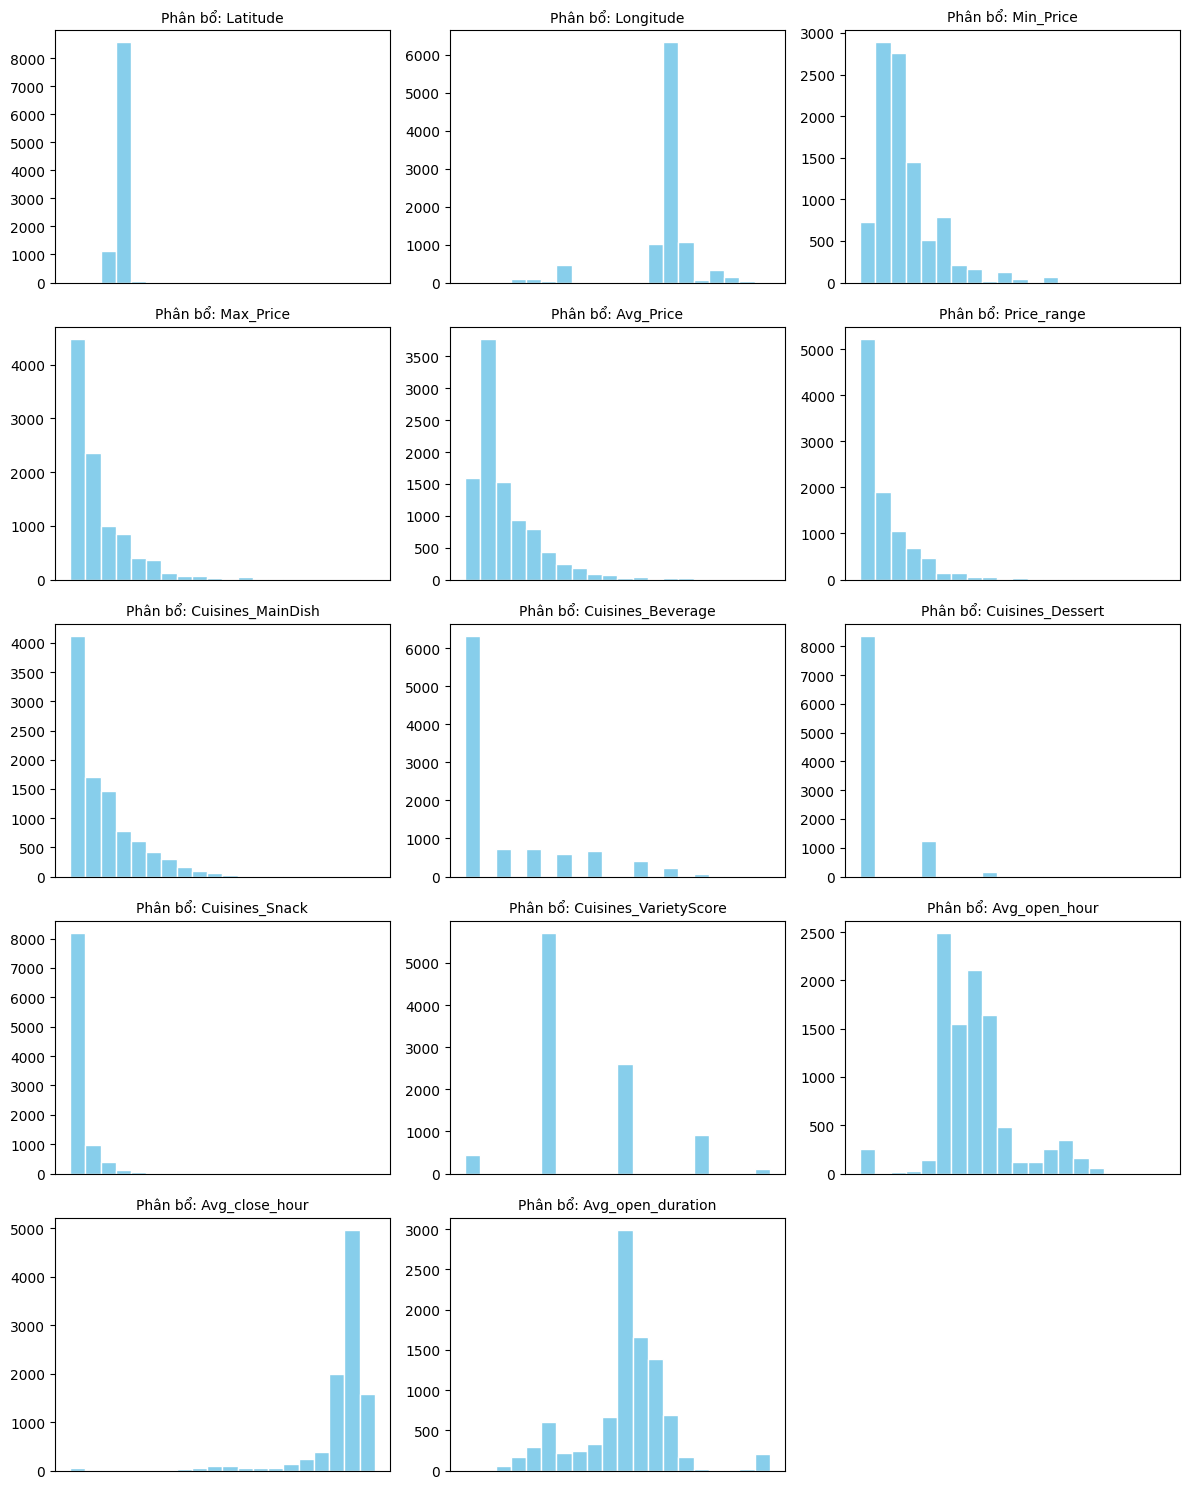

In [27]:
# Lọc cột cần Scaling
need_scaling = train_unscaled.columns[train_unscaled.nunique() > 2].tolist() # bỏ cột binary và hằng số
need_scaling = [col for col in need_scaling if col != 'preference_level'] # bỏ cột nhãn
binaries_label = [col for col in train_unscaled.columns if col not in need_scaling] # Binary và nhãn

print(f"Các cột cần scaling: {need_scaling}\nTổng: {len(need_scaling)} cột")

# Gọi hàm vẽ biểu đồ các cột
plot_need_scaling(train_unscaled, need_scaling)

* Scaling

In [28]:
# Các nhóm cột chung kiểu phân phối
cols_skew =['Avg_open_duration', 'Avg_close_hour', 'Avg_open_hour', 'Cuisines_MainDish', 'Cuisines_Beverage', 
            'Cuisines_Dessert', 'Cuisines_Snack', 'Cuisines_VarietyScore', 'Min_Price', 'Max_Price', 'Avg_Price', 'Price_range']
cols_uniform = ['Latitude', 'Longitude']
cols_standard = [col for col in need_scaling if (col not in cols_skew) and (col not in cols_uniform)]

# Tạo transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), cols_standard),
        ('robust', RobustScaler(), cols_skew), # áp dụng Robust cho cột phân phối lệch
        ('minmax', MinMaxScaler(), cols_uniform)
    ]
)
# Đúng thứ tự trên
scaling_cols = cols_standard + cols_skew + cols_uniform

# Fit-transform train
train_scaled = preprocessor.fit_transform(train_unscaled[scaling_cols])
train_scaled = pd.DataFrame(train_scaled, columns=scaling_cols, index=train_unscaled.index)
# Gộp lại với các cột nhị phân và cột nhãn
train_transformed = pd.concat([train_scaled, train_unscaled[binaries_label]], axis=1)

# Transform test
test_scaled = preprocessor.transform(test_unscaled[scaling_cols])
test_scaled = pd.DataFrame(test_scaled, columns=scaling_cols, index=test_unscaled.index)
test_transformed = pd.concat([test_scaled, test_unscaled[binaries_label]], axis=1)

# Xuất file đã scaling
train_transformed.to_csv('../data/data_processed/train/train_scaled.csv', index=False, encoding='utf-8-sig')
test_transformed.to_csv('../data/data_processed/test/test_scaled.csv', index=False, encoding='utf-8-sig')

* Mapping biến mục tiêu

In [29]:
train_transformed['preference_level'] = train_transformed['preference_level'].map({'high': 2, 'moderate': 1, 'low': 0}).astype('int32')
test_transformed['preference_level'] = test_transformed['preference_level'].map({'high': 2, 'moderate': 1, 'low': 0}).astype('int32')

* Phân tích tương quan và chọn lọc Feature

In [30]:
# Phân tích tương quan và đề xuất bỏ cột
to_drop, corr_with_target = analyze_and_filter_correlations(train_transformed, target_col='preference_level')

--- Đề xuất loại bỏ do tương quan quá cao (> 0.85): ---
['Avg_Price', 'Price_range']

--- Độ tương quan với 'preference_level': ---
Is_open_weekend             0.106791
Style_Taiwanese             0.106220
Style_Chinese               0.100355
Style_Thai                  0.087761
Type_quán ăn                0.049542
Style_Italian               0.042685
Style_Filipino              0.042385
Style_Other                 0.038543
Type_café/dessert           0.036391
Style_Cambodian             0.035841
Same_Min_Max                0.022640
Style_Malaysian             0.015588
Is_Vegetarian               0.012370
Style_American              0.012140
Cuisines_Beverage           0.011502
Is_Healthy                  0.011191
Is_open_after_22            0.010949
Type_nhà hàng sang trọng    0.007505
Type_ăn vặt/vỉa hè          0.007422
Style_International         0.007124
Style_Spanish               0.005012
Type_shop online            0.000261
Style_French               -0.002802
Type_quán nhậu   

* Xóa cột Avg_Price

In [31]:
# Xóa cột Avg_Price để hạn chế sai số
train_reduced = train_transformed.drop(columns = ['Avg_Price'])
test_reduced = test_transformed.drop(columns = ['Avg_Price'])

# Xuất file đã bỏ cột tương quan
train_reduced.to_csv('../data/data_processed/train/train_reduced.csv', index=False, encoding='utf-8-sig')
test_reduced.to_csv('../data/data_processed/test/test_reduced.csv', index=False, encoding='utf-8-sig')

# VII. Modeling

In [32]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, precision_score

# Train set
X_train = train_reduced.drop(columns=['preference_level']).values
y_train = train_reduced['preference_level'].values

# Validation set
X_test = test_reduced.drop(columns=['preference_level']).values
y_test = test_reduced['preference_level'].values

model = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=6, min_samples_leaf=4)
model.fit(X_train, y_train)
y_hat = model.predict(X_test).astype(int)
y_valid = y_test.astype(int)

print(f"F1: {f1_score(y_valid, y_hat, average='macro')} | Recall: {recall_score(y_valid, y_hat, average='macro')} | Precision: {precision_score(y_valid, y_hat, average='macro')}")

F1: 0.4771210493887665 | Recall: 0.4822989770841835 | Precision: 0.4916178146010493


# **Phần III: Phân tích khám phá dữ liệu (n3_exploratory_data_analysis)**
_ Phần EDA chi tiết dữ liệu đã qua tiền xử lý đã có trong file: **notebooks/n3_exploratory_data_analysis/EDA_processed.ipynb**\
_ Bao gồm 2 file: 
* **EDA_raw.ipynb** dùng cho phân tích dữ liệu sau khi thu thập từ các websites; 
* **EDA_preprocessed.ipynb** phân tích khám phá dữ liệu sau bước tiền xử lý.\

Kính mời độc giả đọc qua!